# Supplementary Figure S4b — Optimal n-plets on the combined MA + DBS dataset

Each of the four optimal n-plets is evaluated on the **combined MA + DBS** scan pool,
with the Awake state from both datasets treated as the conscious class and
all other states as the non-responsive class.

Violin plots show $\Omega$ distributions across all conditions from both datasets
side by side (MA states left, DBS states right).

**Optimal n-plets**:

| Source | Polarity | n-plet |
|--------|----------|--------|
| MA | $\Omega_C > \Omega_{NR}$ | `[7, 14, 23, 26, 35, 55, 67]` |
| MA | $\Omega_{NR} > \Omega_C$ | `[38, 40, 45, 81]` |
| DBS | $\Omega_C > \Omega_{NR}$ | `[6, 8, 12, 18, 20, 22, 59, 61, 63]` |
| DBS | $\Omega_{NR} > \Omega_C$ | `[3, 4, 10]` |

In [1]:
from pathlib import Path
import os

def ensure_project_root(target_name: str = "high-order-anesthesia") -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name == target_name:
        return cwd
    for parent in cwd.parents:
        if parent.name == target_name:
            os.chdir(parent)
            return parent
    raise RuntimeError(f"Could not find '{target_name}' in path.")

ROOT = ensure_project_root()
print(f"Now in: {ROOT.name}")

Now in: high-order-anesthesia


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from thoi.measures.gaussian_copula import nplets_measures
from src.hoi_anesthesia.io import load_covariance_dict

In [3]:
results_path = "results"
data_path    = "data"
FONTSIZE     = 12
plt.rcParams.update({"font.size": FONTSIZE})

all_covs = load_covariance_dict(f"{data_path}/covariance_matrices_gc.h5")

optimal_nplets = [
    {"src": "MA",  "polarity": "c_gt_nr", "nodes": [7, 14, 23, 26, 35, 55, 67],
     "label": r"MA-origin, $\Omega_C > \Omega_{NR}$"},
    {"src": "MA",  "polarity": "nr_gt_c", "nodes": [38, 40, 45, 81],
     "label": r"MA-origin, $\Omega_{NR} > \Omega_C$"},
    {"src": "DBS", "polarity": "c_gt_nr", "nodes": [6, 8, 12, 18, 20, 22, 59, 61, 63],
     "label": r"DBS-origin, $\Omega_C > \Omega_{NR}$"},
    {"src": "DBS", "polarity": "nr_gt_c", "nodes": [3, 4, 10],
     "label": r"DBS-origin, $\Omega_{NR} > \Omega_C$"},
]

custom_order = {
    "MA":  ["MA_awake", "ts_selv2", "ts_selv4", "moderate_propofol", "deep_propofol", "ketamine"],
    "DBS": ["DBS_awake", "ts_on_5V", "ts_on_3V", "ts_on_5V_control", "ts_on_3V_control", "ts_off"],
}
pretty_labels = {
    "MA_awake":           "MA Awake",
    "ts_selv2":           "2% Sevo",
    "ts_selv4":           "4% Sevo",
    "deep_propofol":      "Deep Ppfl",
    "moderate_propofol":  "Light Ppfl",
    "ketamine":           "Ketamine",
    "DBS_awake":          "DBS Awake",
    "ts_on_5V":           "CT high",
    "ts_off":             "off",
    "ts_on_3V_control":   "VT low",
    "ts_on_5V_control":   "VT high",
    "ts_on_3V":           "CT low",
}
state_colors = {
    "MA_awake":           "#FF9900",
    "ts_selv2":           "#75EACC",
    "ts_selv4":           "#00A073",
    "moderate_propofol":  "#CEB8F2",
    "deep_propofol":      "#9C7AD8",
    "ketamine":           "#B0B900",
    "DBS_awake":          "#FF9900",
    "ts_on_5V":           "#FFD166",
    "ts_off":             "#9C7AD8",
    "ts_on_3V_control":   "#109121",
    "ts_on_5V_control":   "#109121",
    "ts_on_3V":           "#757575",
}
# Combined state order: MA states then DBS states
combined_order = custom_order["MA"] + custom_order["DBS"]

## Violin plots: each n-plet on the combined MA + DBS scan pool

C:\Users\camil\AppData\Local\Temp\ipykernel_2676\3660665627.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\camil\AppData\Local\Temp\ipykernel_2676\3660665627.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\camil\AppData\Local\Temp\ipykernel_2676\3660665627.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\camil\AppData\Local\Temp\ipykernel_2676\3660665627.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


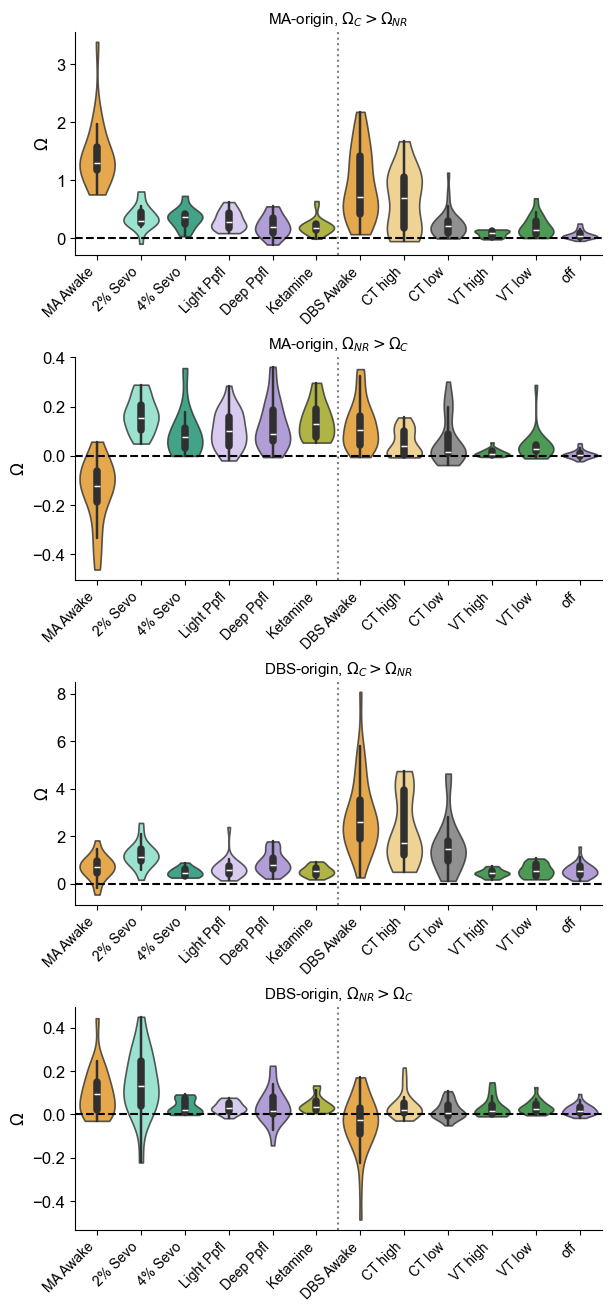

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(6, 13), constrained_layout=True)
sns.set_style("white")
n_ma_states = len(custom_order["MA"])

for ax, nplet_info in zip(axes, optimal_nplets):
    nplet = nplet_info["nodes"]
    records = []

    for dataset in ["MA", "DBS"]:
        for state in combined_order:
            if state not in all_covs.get(dataset, {}):
                continue
            cov_t    = torch.as_tensor(all_covs[dataset][state])
            measures = nplets_measures(cov_t, nplets=[nplet], covmat_precomputed=True)
            for subj in range(measures.shape[1]):
                records.append({"state": state, "O": measures[0, subj, 2].item(),
                                 "dataset": dataset})

    df = pd.DataFrame(records)
    order_present = [s for s in combined_order if s in df["state"].values]
    pal = {s: state_colors[s] for s in order_present}

    sns.violinplot(
        data=df, x="state", y="O", hue="state", legend=False,
        inner="box", palette=pal, dodge=False, alpha=0.8, cut=0,
        order=order_present, linewidth=1.2, ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", zorder=1)

    # Vertical separator between MA and DBS states
    n_ma_present = sum(1 for s in custom_order["MA"] if s in order_present)
    ax.axvline(n_ma_present - 0.5, color="gray", linestyle=":", lw=1.5)

    ax.set_xticklabels(
        [pretty_labels[s] for s in order_present], rotation=45, ha="right",
        fontsize=FONTSIZE - 2
    )
    ax.set_xlabel("")
    ax.set_ylabel(r"$\Omega$")
    ax.set_title(nplet_info["label"], fontsize=FONTSIZE - 1)
    sns.despine(ax=ax)

plt.savefig(f"{results_path}/figS4b_combined_dataset_violins.pdf", bbox_inches="tight")
plt.show()